# Grammar Scoring Engine — Final Submission (E022)

Predict a continuous 0–5 grammar score for 45–60 s spoken English recordings.

**Final model:** an equal-weight ensemble of fine-tuned DeBERTa-v3 regressors that read
*three kinds of ASR transcript*: the default Whisper transcript, disfluency-preserving
("verbatim") Whisper transcripts that keep the grammatical errors default Whisper silently
repairs, and a literal wav2vec2 CTC transcript decoded without any language model. This
text ensemble (60%) is blended with a frozen **WavLM audio** regressor (40%) that hears what
transcripts lose: pronunciation, rhythm, pauses and self-repairs.

| Metric (training data, 5-fold out-of-fold, 732 rows) | Value |
| --- | ---: |
| **Training RMSE (OOF, nested)** | computed below — 0.5073 |
| **Training Pearson (OOF, nested)** | computed below — 0.8720 |

This notebook is the report: it explains the approach, preprocessing and architecture,
recomputes every evaluation number from stored prediction artifacts, visualizes the results,
and writes the 216-row `submission.csv`. It does not retrain (training ran on Kaggle/Colab
GPUs with the package code referenced below); only the small audio regressor is refitted
here, so it executes in about a minute on CPU.

## 1. Approach in one paragraph

Grammar is a property of *what was said*, so the pipeline is **audio → ASR transcript →
text regressor**. The key finding of this project is that default Whisper output is too
clean for grammar scoring: its language model drops fillers and false starts and quietly
fixes errors ("I liked *to* playground" → "I liked *the* playground"). Prompting Whisper with
disfluent text makes it transcribe verbatim, which restores that evidence. Each DeBERTa model
is trained on **both** transcripts of every clip (two training examples per recording) and
predicts by averaging over both. Two more views add diversity: a second verbatim variant (v2)
and a wav2vec2 CTC transcript, which has no language model at all and so writes errors
exactly as heard. Seeds and model sizes are averaged with equal weight. Finally, a frozen
WavLM audio model adds information that never reaches a transcript; its 40% weight is the only
fitted blend weight and is chosen by nested cross-validation.

```text
                ┌─ Whisper large-v3 (default)         → canonical transcript ─┐
audio (.wav) ───┤                                                              ├─ DeBERTa-v3 regressor ─┐
                ├─ Whisper large-v3 + disfluent prompt → verbatim v1 ──────────┘  (trained on both)     │
                ├─ Whisper large-v3 + per-window style cue → verbatim v2 ─── DeBERTa-v3 regressor ──────┤
                └─ wav2vec2-large CTC, no language model   → literal CTC ─── DeBERTa-v3 regressor ──────┤
                                                                                                        ▼
               text = equal-weight mean of 6 groups (large/base × dual/v2/CTC, 2–3 seeds each)

audio (.wav) ─── frozen WavLM-base-plus (20 s chunks, mean-pooled) ─── RBF-SVR ─── audio

                          final score = 0.6 × text + 0.4 × audio
```

## 2. Setup

Paths resolve automatically for a local checkout (run from `notebooks/`) or a Kaggle notebook
with the competition data and the private artifact dataset
`lijoraju94/grammar-scoring-e015-final-artifacts` attached. All reusable logic is imported
from the `grammar_scoring` package in this repository.

In [1]:
import json
import subprocess
import sys
from pathlib import Path

ON_KAGGLE = Path("/kaggle/input").exists()
if ON_KAGGLE:
    REPO = Path("/kaggle/working/grammar-scoring")
    if not REPO.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "https://github.com/lijoraju/grammar-scoring.git",
                str(REPO),
            ],
            check=True,
        )
    DATA_DIR = next(Path("/kaggle/input").glob("**/Dataset_Final/train.csv")).parent
    FINAL_DIR = next(
        Path("/kaggle/input").glob("**/grammar-scoring-e015-final-artifacts*")
    )
    CANON_DIR = next(
        Path("/kaggle/input").glob("**/grammar-scoring-canonical-artifacts*")
    )
    OUTPUT_DIR = Path("/kaggle/working")
else:
    REPO = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
    DATA_DIR = REPO / "data/raw/Dataset_Final"
    FINAL_DIR = REPO / "artifacts/final_e015"
    CANON_DIR = REPO / "artifacts/transcripts"
    OUTPUT_DIR = REPO / "artifacts/final_e015"
sys.path.insert(0, str(REPO / "src"))
print("data:", DATA_DIR, "| artifacts:", FINAL_DIR)

data: /Volumes/Transcend/Kaggle Competition/grammar-scoring/data/raw/Dataset_Final | artifacts: /Volumes/Transcend/Kaggle Competition/grammar-scoring/artifacts/final_e015


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from grammar_scoring.evaluation.metrics import regression_metrics
from grammar_scoring.experiments.e014_ensemble import ensemble_report, load_groups
from grammar_scoring.experiments.e014_finetune import load_transcripts
from grammar_scoring.experiments.e022_audio import (
    best_blend_weight,
    load_audio,
    nested_audio_oof,
    nested_blend,
    svr_search,
)
from grammar_scoring.features.disfluency import text_features

# Validated categorical palette (fixed order) and recessive ink for axes and text.
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
INK, MUTED, SURFACE = "#0b0b0b", "#898781", "#fcfcfb"
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": MUTED,
        "axes.labelcolor": INK,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#e6e5e1",
        "grid.linewidth": 0.6,
        "axes.axisbelow": True,
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
    }
)

## 3. Data and preprocessing

* **Rows:** 769 training and 216 test recordings (WAV, 45–60 s). Labels are MOS Likert grammar
  scores in half-point steps.
* **Zero-label block (excluded):** 37 training rows labelled 0, all from one contiguous file
  block (`audio_5037`–`audio_5073`) with heavy background noise and otherwise fluent speech.
  They behave like a different source (they contributed ~43% of squared error in early
  models) and no test file comes from that block, so the final population keeps the
  **732 rows with label > 0**. Filenames are only diagnostic; they are never features.
* **Folds:** five frozen folds created once and reused by every experiment, so all OOF
  numbers are comparable. Validation folds never influence training, checkpoint weights or
  test predictions of their own fold.
* **Audio preprocessing:** Whisper resamples to 16 kHz mono internally; no VAD, no denoising
  and no text normalization are applied, so disfluencies survive into the transcripts.

train rows: 769 | test rows: 216 | zero labels: 37


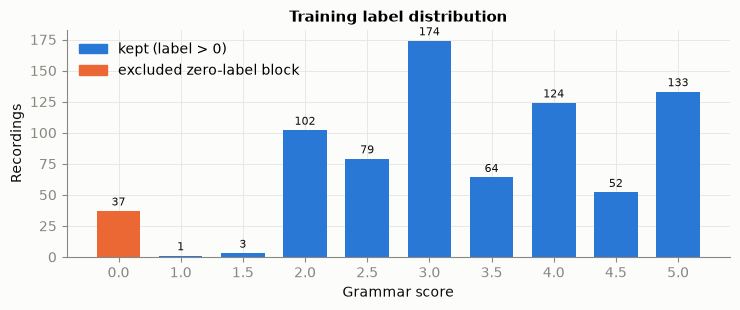

In [3]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
n_zero = int((train.label == 0).sum())
print(f"train rows: {len(train)} | test rows: {len(test)} | zero labels: {n_zero}")

counts = train.label.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7.5, 3.2))
colors = [ORANGE if label == 0 else BLUE for label in counts.index]
bars = ax.bar(counts.index.astype(str), counts.values, color=colors, width=0.7)
ax.bar_label(bars, padding=2, color=INK, fontsize=8)
ax.set(title="Training label distribution", xlabel="Grammar score", ylabel="Recordings")
ax.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, color=BLUE),
        plt.Rectangle((0, 0), 1, 1, color=ORANGE),
    ],
    labels=["kept (label > 0)", "excluded zero-label block"],
    frameon=False,
)
plt.tight_layout()
plt.show()

## 4. ASR: why verbatim transcripts matter

Whisper transcripts come from **faster-whisper large-v3** (English, beam 5, no VAD); the CTC
transcript comes from **wav2vec2-large-960h-lv60-self** with greedy decoding:

| Transcript | Decoding | Purpose |
| --- | --- | --- |
| canonical | default settings, no prompt | clean, well-punctuated text |
| verbatim v1 | disfluent `initial_prompt`, conditioned on previous text | keep fillers, false starts and errors |
| verbatim v2 | disfluent style cue re-inserted in **every** 30 s window, no text conditioning, stricter compression-ratio fallback | same goal, without v1's rare repetition loops / prompt leakage |
| CTC | wav2vec2 frame-level characters, greedy, 20 s chunks with 4 s overlap; lower-case, no punctuation | fully literal: no language model to repair errors |

Code: `src/grammar_scoring/transcription/verbatim.py` (variants `v1`, `v2`) and
`src/grammar_scoring/transcription/ctc.py`. CTC adds literal *words* ("i like to playground",
"a lot kids") rather than fillers, which its read-speech training data lacks. It heard no speech in 17 of the 37
excluded zero-label clips, independent support for treating that block as noisy audio.

In [4]:
versions = {
    "canonical": CANON_DIR,
    "verbatim v1": FINAL_DIR / "transcripts_verbatim_v1",
    "verbatim v2": FINAL_DIR / "transcripts_verbatim_v2",
    "CTC": FINAL_DIR / "transcripts_ctc",
}
texts = {
    name: load_transcripts(path / "train.jsonl") for name, path in versions.items()
}
example = "audio_61.wav"
print(f"{example} — label {train.set_index('filename').label[example]}\n")
for name, mapping in texts.items():
    print(f"[{name}]\n{mapping[example][:330]}…\n")

audio_61.wav — label 2.0

[canonical]
Well, when I was a child, I remember I went to the kindergarten, and I liked the playground. I remember there are a lot of kids, a lot, well, the teacher, and just enjoy your life. didn't think in other those it was so good because you need just enjoy enjoy play play play with the with the land play with the cars or play video g…

[verbatim v1]
Well, when I was a child, I remember I went to the kindergarten and I liked to playground. I remember there are a lot kids, a lot, well, the teacher, um, just enjoy your life. You didn't think in other those, uh, it was so good because you need just enjoy, enjoy, play, play, play with the- with the land, play with the cars, or, …

[verbatim v2]
Well, when I was a child, I remember I went to the kindergarten and I liked the playground. I remember there are a lot kids, a lot, well, the teacher, and just enjoy your life. didn't think in other those, uh, it was so good because you need just enjoy, enjoy, play, p

,canonical,verbatim v1,verbatim v2,CTC
disf_filler_rate,0.34,4.06,3.76,0.24
disf_false_start_rate,0.00,1.86,1.49,0.00


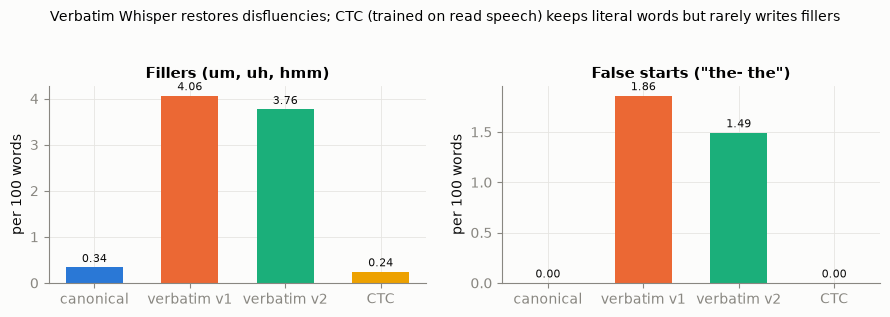

In [5]:
# Disfluency rates per 100 words from the package feature code (labels unused).
canonical = texts["canonical"]
rates = (
    pd.DataFrame(
        {
            name: pd.DataFrame(
                [text_features(canonical[k], mapping[k]) for k in canonical]
            ).mean()
            for name, mapping in texts.items()
        }
    ).loc[["disf_filler_rate", "disf_false_start_rate"]]
    * 100
)
display(rates.round(2))

panels = [
    ("disf_filler_rate", "Fillers (um, uh, hmm)"),
    ("disf_false_start_rate", 'False starts ("the- the")'),
]
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, (metric, title) in zip(axes, panels, strict=True):
    bars = ax.bar(
        rates.columns, rates.loc[metric], color=[BLUE, ORANGE, AQUA, YELLOW], width=0.6
    )
    ax.bar_label(bars, fmt="%.2f", padding=2, color=INK, fontsize=8)
    ax.set(title=title, ylabel="per 100 words")
fig.suptitle(
    "Verbatim Whisper restores disfluencies; CTC (trained on read speech) "
    "keeps literal words but rarely writes fillers",
    y=1.04,
    fontsize=10,
)
plt.tight_layout()
plt.show()

## 5. Model architecture and training

Implemented in `src/grammar_scoring/experiments/e014_finetune.py`:

* **Backbone:** `microsoft/deberta-v3-large` (435M) or `deberta-v3-base` (184M), fully
  fine-tuned; encoder dropout disabled (it hurts regression targets).
* **Head:** attention-mask-aware mean pooling → linear layer; head bias initialised to the
  training-fold mean label.
* **Loss / optimiser:** MSE; AdamW (weight decay 0.01), linear warm-up (10%) and decay,
  5 epochs, effective batch 16, fp16 autocast, max 320 tokens. Large: lr 1e-5 with layer-wise
  LR decay 0.9; base: lr 2e-5. Head lr 1e-3.
* **Dual-transcript training:** every training clip contributes two examples (canonical and
  verbatim v1, same label); validation/test predictions average the two texts.
* **Model selection:** per fold, the epoch with the best validation RMSE (same rule as all
  earlier experiments); its test predictions are kept and averaged over the five folds.
* **Seeds:** 42, 7, 2024 (fixed and recorded per run).

In [6]:
GROUPS = {
    "large_dual": "DeBERTa-large · canonical + verbatim v1",
    "base_dual": "DeBERTa-base · canonical + verbatim v1",
    "large_v2": "DeBERTa-large · verbatim v2",
    "base_v2": "DeBERTa-base · verbatim v2",
    "large_ctc": "DeBERTa-large · CTC",
    "base_ctc": "DeBERTa-base · CTC",
}
run_dirs = {g: sorted((FINAL_DIR / "runs" / g).iterdir()) for g in GROUPS}
rows = []
for group, dirs in run_dirs.items():
    for d in dirs:
        r = json.loads((d / "result.json").read_text())
        rows.append(
            {
                "group": group,
                "run": r["run_name"],
                "seed": r["config"]["seed"],
                "OOF RMSE": r["oof_rmse"],
                "OOF Pearson": r["oof_pearson"],
                "GPU": r["device"],
                "minutes": r["minutes"],
            }
        )
runs_table = pd.DataFrame(rows)
display(runs_table.round(4))

,group,run,seed,OOF RMSE,OOF Pearson,GPU,minutes
0,large_dual,deberta-v3-large_dual_lr1e-05_s2024,2024,0.5818,0.8197,Tesla T4,41.3381
1,large_dual,deberta-v3-large_dual_lr1e-05_s42,42,0.5685,0.8284,Tesla T4,39.8586
2,large_dual,deberta-v3-large_dual_lr1e-05_s7,7,0.5882,0.8159,Tesla T4,39.2701
3,base_dual,deberta-v3-base_dual_lr2e-05_s2024,2024,0.5864,0.8158,Tesla T4,11.8509
4,base_dual,deberta-v3-base_dual_lr2e-05_s42,42,0.5787,0.8213,Tesla T4,12.3974
5,base_dual,deberta-v3-base_dual_lr2e-05_s7,7,0.5848,0.8172,Tesla T4,11.8354
6,large_v2,deberta-v3-large_lr1e-05_s42,42,0.5762,0.8241,Tesla T4,19.2211
7,large_v2,deberta-v3-large_lr1e-05_s7,7,0.5785,0.8227,Tesla T4,19.0433
8,base_v2,deberta-v3-base_lr2e-05_s42,42,0.5929,0.8127,Tesla T4,6.0521
9,base_v2,deberta-v3-base_lr2e-05_s7,7,0.5931,0.8119,Tesla T4,5.6341


## 6. Text ensemble (out-of-fold on the training data)

Every prediction below comes from a model that never saw that row: row *i* in fold *k* is
predicted by the fold-*k* model trained on the other four folds. Seeds are averaged inside
each group, and the six groups are averaged with equal weight.

In [7]:
oof, test_pred = load_groups(run_dirs)
report = ensemble_report(oof, list(GROUPS))
summary = pd.DataFrame(
    [{"model": GROUPS[g], "runs": len(run_dirs[g]), **report[g]} for g in GROUPS]
    + [
        {
            "model": "TEXT ENSEMBLE: equal-weight mean of the 6 groups",
            "runs": sum(map(len, run_dirs.values())),
            **report["mean"],
        }
    ]
).rename(columns={"rmse": "RMSE", "pearson_correlation": "Pearson"})
display(summary.round(4))
text_oof = oof[list(GROUPS)].mean(axis=1).to_numpy()
text_test = test_pred[list(GROUPS)].mean(axis=1).to_numpy()
y = oof["label"].to_numpy()
folds = oof["fold"].to_numpy()

,model,runs,RMSE,Pearson
0,DeBERTa-large · canonical + verbatim v1,3,0.5704,0.8269
1,DeBERTa-base · canonical + verbatim v1,3,0.5732,0.8249
2,DeBERTa-large · verbatim v2,2,0.5699,0.8279
3,DeBERTa-base · verbatim v2,2,0.5826,0.8188
4,DeBERTa-large · CTC,2,0.5894,0.8148
5,DeBERTa-base · CTC,2,0.6099,0.7999
6,TEXT ENSEMBLE: equal-weight mean of the 6 groups,14,0.5466,0.8426


## 7. Audio channel and final blend

`src/grammar_scoring/experiments/e022_audio.py`. Each recording is encoded by frozen
`microsoft/wavlm-base-plus` (`features/wavlm.py`: 20 s chunks, final-layer masked mean,
duration-weighted; extracted on GPU, test embeddings verified to reproduce the training
pipeline at cosine 1.0000). A standardized RBF support-vector regressor maps the 768-d
embedding to a score.

* **Nested CV, no leakage:** for each outer fold the scaler and SVR are fitted on the other
  four folds, and the SVR's `C`/`epsilon` are chosen by an inner 4-fold search inside them.
* **Blend weight:** chosen per outer fold on the other folds only (nested), so the reported
  blend RMSE is honest; the final 40% weight is the same choice made on all OOF predictions.
* **Why not E009?** The same embeddings with `Ridge(alpha=1.0)` scored 0.90: far too little
  regularization for 768 features and ~585 rows. The RBF-SVR fixes that.

In [8]:
AUDIO_DIR = FINAL_DIR / "audio"
train_x = load_audio(
    AUDIO_DIR / "train_embeddings.npy",
    AUDIO_DIR / "train_metadata.csv",
    oof["filename"].tolist(),
)
test_x = load_audio(
    AUDIO_DIR / "test_embeddings.npy",
    AUDIO_DIR / "test_metadata.csv",
    test_pred["filename"].tolist(),
)
audio_oof, fold_params = nested_audio_oof(train_x, y, folds)
final_oof, fold_weights = nested_blend(text_oof, audio_oof, y, folds)
display(
    pd.DataFrame(
        [
            {"model": "text ensemble (6 groups)", **regression_metrics(y, text_oof)},
            {
                "model": "audio: WavLM + RBF-SVR (nested)",
                **regression_metrics(y, audio_oof),
            },
            {
                "model": "FINAL: text + audio, nested blend",
                **regression_metrics(y, final_oof),
            },
        ]
    )
    .rename(columns={"rmse": "RMSE", "pearson_correlation": "Pearson"})
    .round(4)
)
print("audio weight chosen per outer fold:", fold_weights)
print(f"corr(text, audio) on OOF: {np.corrcoef(text_oof, audio_oof)[0, 1]:.3f}")
train_metrics = regression_metrics(y, final_oof)
print(
    f"TRAINING DATA RMSE (5-fold out-of-fold, nested, n={len(y)}): "
    f"{train_metrics['rmse']:.4f}"
)
print(
    f"TRAINING DATA Pearson (5-fold out-of-fold, nested):        "
    f"{train_metrics['pearson_correlation']:.4f}"
)

,model,RMSE,Pearson
0,text ensemble (6 groups),0.5466,0.8426
1,audio: WavLM + RBF-SVR (nested),0.5858,0.8166
2,"FINAL: text + audio, nested blend",0.5073,0.8720


audio weight chosen per outer fold: [0.45, 0.45, 0.4, 0.4, 0.4]
corr(text, audio) on OOF: 0.812
TRAINING DATA RMSE (5-fold out-of-fold, nested, n=732): 0.5073
TRAINING DATA Pearson (5-fold out-of-fold, nested):        0.8720


**Training RMSE.** The required training-data RMSE is reported as the 5-fold out-of-fold
RMSE above: it is computed on the full training population, but each score is predicted by
a model that did not train on it, so it estimates performance on unseen speakers instead of
measuring memorization (in-sample RMSE of a fine-tuned transformer is near zero and says
nothing about generalization).

In [9]:
per_fold = pd.DataFrame(
    [
        {
            "fold": k,
            "n": int((folds == k).sum()),
            "text RMSE": regression_metrics(y[folds == k], text_oof[folds == k])[
                "rmse"
            ],
            **regression_metrics(y[folds == k], final_oof[folds == k]),
        }
        for k in sorted(np.unique(folds))
    ]
).rename(columns={"rmse": "RMSE", "pearson_correlation": "Pearson"})
display(per_fold.round(4))
print(f"fold RMSE mean ± std: {per_fold.RMSE.mean():.4f} ± {per_fold.RMSE.std():.4f}")

,fold,n,text RMSE,RMSE,Pearson
0,0,147,0.5518,0.5290,0.8644
1,1,150,0.5773,0.5526,0.8581
2,2,146,0.5169,0.4589,0.8922
3,3,141,0.5101,0.4615,0.8856
4,4,148,0.5709,0.5244,0.8660


fold RMSE mean ± std: 0.5053 ± 0.0425


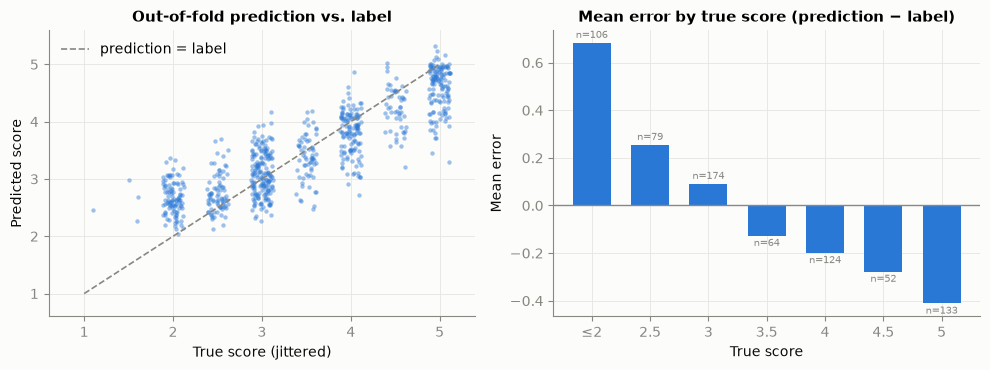

In [10]:
rng = np.random.default_rng(42)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
ax = axes[0]
ax.scatter(
    y + rng.uniform(-0.12, 0.12, len(y)),
    final_oof,
    s=10,
    alpha=0.45,
    color=BLUE,
    linewidths=0,
)
ax.plot(
    [1, 5],
    [1, 5],
    color=MUTED,
    linewidth=1.2,
    linestyle="--",
    label="prediction = label",
)
ax.legend(frameon=False, loc="upper left")
ax.set(
    title="Out-of-fold prediction vs. label",
    xlabel="True score (jittered)",
    ylabel="Predicted score",
    xlim=(0.6, 5.4),
    ylim=(0.6, 5.6),
)

bands = pd.cut(
    y,
    [0, 2.25, 2.75, 3.25, 3.75, 4.25, 4.75, 5.0],
    labels=["≤2", "2.5", "3", "3.5", "4", "4.5", "5"],
)
by_band = (
    pd.DataFrame({"band": bands, "residual": final_oof - y})
    .groupby("band", observed=True)["residual"]
    .agg(["mean", "size"])
)
ax = axes[1]
bars = ax.bar(by_band.index.astype(str), by_band["mean"], color=BLUE, width=0.65)
ax.bar_label(
    bars, labels=[f"n={n}" for n in by_band["size"]], padding=2, fontsize=7, color=MUTED
)
ax.axhline(0, color=MUTED, linewidth=1)
ax.set(
    title="Mean error by true score (prediction − label)",
    xlabel="True score",
    ylabel="Mean error",
)
plt.tight_layout()
plt.show()

The model ranks speakers well (Pearson ≈ 0.87) but, like most regressors trained with MSE on a
small dataset, it shrinks towards the mean: it over-scores the weakest speakers and
under-scores the strongest. A cross-validated linear stretch did not reduce RMSE (tested in
E014), so predictions are submitted raw.

## 8. Does the audio gain generalize? (leakage check)

Recordings arrive in batches: labels of neighbouring file IDs correlate strongly, so a model
can partly score a clip by recognizing its batch (speakers, prompts, recording setup) rather
than its grammar. Audio is far more exposed to this than text. Two checks:

In [11]:
ids = oof["filename"].str.extract(r"(\d+)")[0].astype(int).to_numpy()
order = np.argsort(ids)
print(
    f"corr(label, label of the next file ID): "
    f"{np.corrcoef(y[order][:-1], y[order][1:])[0, 1]:.3f}"
)

splits = {
    "random (frozen folds)": [
        (np.where(folds != k)[0], np.where(folds == k)[0]) for k in range(5)
    ]
}
for block in (25, 50, 100):
    splits[f"grouped, blocks of {block} IDs"] = list(
        GroupKFold(5).split(train_x, y, ids // block)
    )
rows = []
for name, split in splits.items():
    pred = np.empty(len(y))
    for tr, va in split:  # fixed SVR settings so only the fold design changes
        model = svr_search(4).estimator.set_params(svr__C=3.0, svr__epsilon=0.2)
        pred[va] = model.fit(train_x[tr], y[tr]).predict(train_x[va])
    rows.append({"folds": name, "audio-only RMSE": regression_metrics(y, pred)["rmse"]})
display(pd.DataFrame(rows).round(4))

domain_x = np.vstack([train_x, test_x])
domain_y = np.r_[np.zeros(len(train_x)), np.ones(len(test_x))]
domain_p = cross_val_predict(
    make_pipeline(StandardScaler(), LogisticRegression(C=0.1, max_iter=2000)),
    domain_x,
    domain_y,
    cv=5,
    method="predict_proba",
)[:, 1]
print(
    f"train-vs-test audio classifier AUC: {roc_auc_score(domain_y, domain_p):.3f} "
    "(0.5 = indistinguishable)"
)

corr(label, label of the next file ID): 0.514


,folds,audio-only RMSE
0,random (frozen folds),0.5979
1,"grouped, blocks of 25 IDs",0.6641
2,"grouped, blocks of 50 IDs",0.6792
3,"grouped, blocks of 100 IDs",0.7186


train-vs-test audio classifier AUC: 0.761 (0.5 = indistinguishable)


**Reading the checks.** Grouping folds by file-ID block costs the audio model about 0.12 RMSE,
while a text stand-in (frozen DeBERTa embeddings + the same SVR, recorded in
`docs/E014_E022.md`) loses only about 0.03; even under the strictest grouping, adding audio to
that text model still helped (blend 0.626 vs text 0.654). Test audio is also partly from
different batches (a train-vs-test classifier reaches AUC ≈ 0.76–0.82 depending on the
split, well above the 0.5 of identical distributions). So the 0.507 OOF figure is optimistic for new
recording sources, but the audio channel still carries real signal, and the public
leaderboard confirmed it: a single submission at the CV-chosen weight improved the score from
0.3712 (text only) to **0.3605**. No weight was tuned on the leaderboard.

## 9. How we got here (experiment log)

Values are the recorded OOF metrics of each submitted ensemble and the public leaderboard
score Kaggle returned for it (lower is better). Public scores use part of the 216 test rows
and move by a few thousandths from noise alone, so model choices were made on OOF only.

,submission,OOF RMSE,OOF Pearson,public LB
0,"E008 DeBERTa-base, canonical",0.6198,0.7942,0.3925
1,E014 + multi-seed base & large,0.5732,0.8250,0.3894
2,E015 + base on verbatim v1,0.5670,0.8290,0.3816
3,E015 4 groups (canonical/verbatim),0.5626,0.8319,0.3755
4,E015 dual-transcript large+base,0.5603,0.8336,0.3800
5,E015 dual + verbatim v2,0.5545,0.8372,0.3778
6,E020 + wav2vec2 CTC,0.5466,0.8426,0.3712
7,E022 + WavLM audio (final),0.5073,0.8720,0.3605


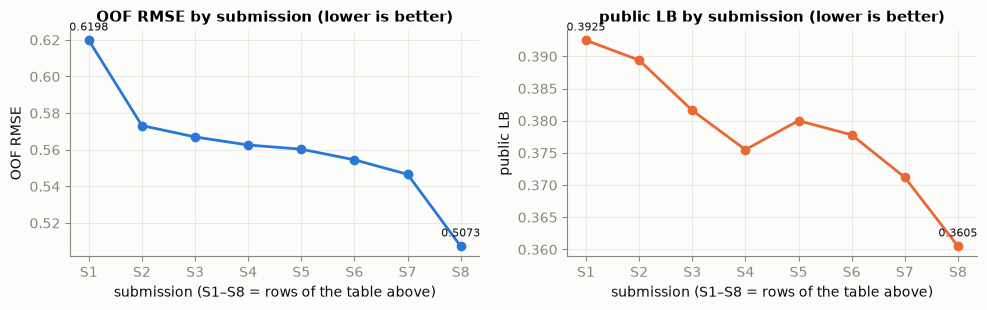

In [12]:
log = pd.DataFrame(
    [
        ("E008 DeBERTa-base, canonical", 0.6198, 0.7942, 0.3925),
        ("E014 + multi-seed base & large", 0.5732, 0.8250, 0.3894),
        ("E015 + base on verbatim v1", 0.5670, 0.8290, 0.3816),
        ("E015 4 groups (canonical/verbatim)", 0.5626, 0.8319, 0.3755),
        ("E015 dual-transcript large+base", 0.5603, 0.8336, 0.3800),
        ("E015 dual + verbatim v2", 0.5545, 0.8372, 0.3778),
        ("E020 + wav2vec2 CTC", 0.5466, 0.8426, 0.3712),
        (
            "E022 + WavLM audio (final)",
            train_metrics["rmse"],
            train_metrics["pearson_correlation"],
            0.3605,
        ),
    ],
    columns=["submission", "OOF RMSE", "OOF Pearson", "public LB"],
)
display(log.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharex=True)
x = np.arange(len(log))
for ax, column, color in [(axes[0], "OOF RMSE", BLUE), (axes[1], "public LB", ORANGE)]:
    ax.plot(x, log[column], color=color, linewidth=2, marker="o", markersize=6)
    ax.set(title=f"{column} by submission (lower is better)", ylabel=column)
    ax.set_xticks(x, [f"S{i + 1}" for i in x])
    ax.set_xlabel(f"submission (S1–S{len(log)} = rows of the table above)")
    best = int(np.argmin(log[column]))
    for i, v in enumerate(log[column]):
        if i in (0, len(log) - 1, best):
            ax.annotate(
                f"{v:.4f}",
                (i, v),
                textcoords="offset points",
                xytext=(0, 7),
                ha="center",
                fontsize=8,
                color=INK,
            )
plt.tight_layout()
plt.show()

**Tried and rejected (OOF gate: must improve pooled RMSE *and* at least 4 of 5 folds):**

| Experiment | Result | Why rejected |
| --- | --- | --- |
| Handcrafted acoustic features + stacking (E006a, E012a, E013) | ≤0.005 gain | did not transfer to the leaderboard |
| WavLM + Ridge(alpha=1) (E009) | OOF RMSE 0.900 | under-regularized; replaced by the E022 RBF-SVR |
| CORAL ordinal head (E007) | no gain | |
| Qwen2.5-7B QLoRA regressor (E016) | OOF RMSE 0.710 | weaker than DeBERTa; +10% blend within noise |
| GEC edit rate + zero-shot LLM rubric judge features (E017) | ≤0.003 | correlate with the label but not with ensemble residuals |
| Disfluency / fluency / length features (E019) | 0.004 | only 3 of 5 folds improved |
| RoBERTa-large dual transcripts as a 7th text group (E021) | 0.5443 vs 0.5466 | only 3 of 5 folds improved |
| Tree / Ridge stackers instead of fixed weights | 0.549–0.589 | worse than simple weighting on 732 rows |
| OOF linear calibration; rounding to the 0.5 grid | no gain / worse | rounding hurt every fold |

## 10. Submission

Text ensemble test predictions (fold-averaged per run) are blended with the audio SVR refitted
on all 732 training rows (its `C`/`epsilon` chosen by 5-fold CV), using the 40% audio weight
chosen on the OOF predictions. The file is checked against the exact submission scored on the
public leaderboard (0.3605).

audio weight: 0.4 | final SVR: {'svr__C': 10.0, 'svr__epsilon': 0.05}
wrote /Volumes/Transcend/Kaggle Competition/grammar-scoring/artifacts/final_e015/submission.csv (216 rows)
identical to the scored E022 submission: True


,count,mean,std,min,25%,50%,75%,max
label,216.0,3.315,0.75,1.986,2.72,3.147,3.717,5.183


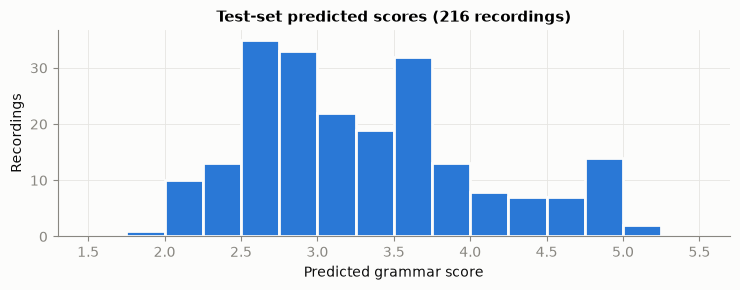

In [13]:
audio_weight = best_blend_weight(text_oof, audio_oof, y)
final_svr = svr_search(5).fit(train_x, y)
print("audio weight:", audio_weight, "| final SVR:", final_svr.best_params_)
submission = pd.DataFrame(
    {
        "filename": test_pred["filename"],
        "label": (1 - audio_weight) * text_test
        + audio_weight * final_svr.predict(test_x),
    }
)
assert submission["filename"].tolist() == test["filename"].tolist()
assert len(submission) == 216 and submission["filename"].is_unique
assert np.isfinite(submission["label"]).all()
path = OUTPUT_DIR / "submission.csv"
submission.to_csv(path, index=False)
print(f"wrote {path} ({len(submission)} rows)")
scored = FINAL_DIR / "e022" / "submission.csv"
if scored.exists():
    print(
        "identical to the scored E022 submission:",
        np.allclose(
            pd.read_csv(scored)["label"], submission["label"], rtol=0, atol=1e-12
        ),
    )
display(submission.describe().round(3).T)

fig, ax = plt.subplots(figsize=(7.5, 3))
bins = np.arange(1.5, 5.6, 0.25)
ax.hist(submission["label"], bins=bins, color=BLUE, edgecolor=SURFACE, linewidth=2)
ax.set(
    title="Test-set predicted scores (216 recordings)",
    xlabel="Predicted grammar score",
    ylabel="Recordings",
)
plt.tight_layout()
plt.show()

## 11. Limitations and next steps

* **ASR dependence.** Scores inherit ASR errors; verbatim decoding is prompt-driven and a few
  files still contain repetition loops, and the CTC model (trained on native read speech)
  makes more spelling-level errors on accented speech.
* **Audio batch effects.** Part of the audio model's CV strength comes from recognizing
  recording batches, and test audio is partly from different batches (Section 8); speaker or
  source IDs would allow properly grouped folds.
* **Shrinkage.** Extreme speakers are pulled towards the mean (Section 7).
* **Small data.** 732 labelled clips; seed-to-seed RMSE varies by ±0.005, which is why seeds
  are averaged and decisions require consistent per-fold gains.
* **Zero-label block.** Excluding it is an empirical choice for a distribution mismatch, not
  proof that those labels are wrong.

## 12. Reproducing the training runs

Each group is one command per seed (GPU, ~5–20 min per seed on a T4):

```sh
python scripts/transcribe_verbatim.py --data-dir <Dataset_Final> --output-dir <out> --variant v1|v2
python scripts/run_e014_finetune.py --data-dir <Dataset_Final> --transcript-dir <canonical> \
    --alt-transcript-dir <verbatim_v1> --model-name microsoft/deberta-v3-large \
    --learning-rate 1e-5 --layer-decay 0.9 --gradient-checkpointing --seeds 42 7 2024 \
    --output-dir <runs>
python scripts/run_e014_ensemble.py --group <runs of group 1> ... --output submission.csv
python scripts/run_e022_audio.py --runs-dir <runs> --groups large_dual base_dual ... \
    --audio-dir <WavLM train/test embeddings> --output-dir <out>
```